In [1]:
import pandas as pd
user_category_df = pd.read_csv(r"D:\내 자료실(이동,삭제 절대금지~~!!)\Desktop\data analysis\Proj_1 e_cummerce\Python\user_category.csv")

In [2]:
user_category_df.head()

,user_id,category_id,product_cnt,event_cnt,purchase_flag,purchase_category_cnt
0,10300217,2053013563424899933,1,1,0,0
1,29515875,2053013554415534427,2,5,0,0
2,29515875,2053013557192163841,3,6,0,0
3,31198833,2053013553559896355,1,1,0,0
4,31198833,2053013554751078769,1,1,0,0


In [3]:
# 카테고리 내, 상품별 평균 집중도

user_category_df["concentration"]=user_category_df["event_cnt"]/user_category_df["product_cnt"]

In [4]:
# 유저별 category_cnt 와 집중도 평균

summary=(user_category_df.groupby("user_id")
    .agg(category_cnt=("category_id","nunique"), concentration=("concentration", "mean"))
    .reset_index())

In [5]:
summary.head()

,user_id,category_cnt,concentration
0,10300217,1,1.000000
1,29515875,2,2.250000
2,31198833,3,1.041667
3,34916060,1,1.000000
4,41798457,1,1.000000


In [6]:
# 그래프 전 임시프레임

tmp = (summary.groupby("category_cnt")["concentration"]
      .mean()
      .reset_index())

In [7]:
# category_cnt 극단조사

summary["category_cnt"].quantile([0.99,0.995,0.999])

0.990    19.0
0.995    25.0
0.999    39.0
Name: category_cnt, dtype: float64

In [8]:
tmp = tmp[tmp["category_cnt"] <= 39]

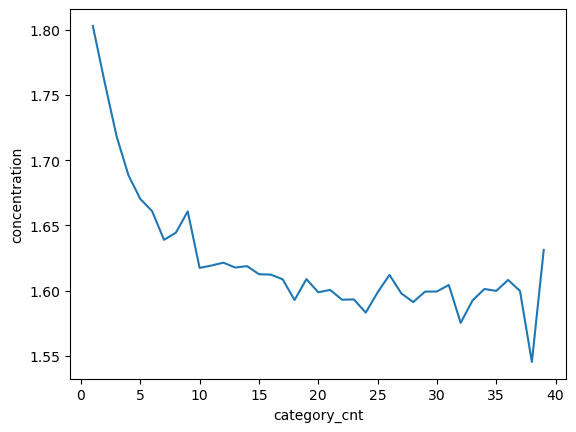

In [9]:
# category_cnt 와 상품별 집중도 관계

import matplotlib.pyplot as plt

plt.plot(
    tmp["category_cnt"],
    tmp["concentration"]
)

plt.xlabel("category_cnt")
plt.ylabel("concentration")

plt.show()